# Images – To Do List



Prior to starting this problem, be sure to enable the GPU runtime processing in your Jupyter notebook.



## Problem Definition



* Write a concise problem definition for the project. Put it in a text field at the top of your Jupyter notebook.

* Load necessary packages.



## Data Collection


In [1]:
import pandas as pd
import tensorflow.keras as keras
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from keras.models import Sequential
from keras.layers import Dense, Input, Flatten, Conv2D, MaxPooling2D
from keras.utils import plot_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle

In [2]:
images_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
images_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'

In [3]:
image = pd.read_pickle( images_url )
type(image)


numpy.ndarray

In [4]:
image.shape

(24946, 100, 100, 1)

In [5]:
target_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"
target_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'


* Load pickled data from X.pickle and y.pickle from the AWS S3 bucket.



In [7]:
target = pd.read_pickle( target_url )
type(target)


list

In [10]:
target = np.array(target)


In [11]:
type(target)

numpy.ndarray

In [12]:
image = image[:500]
target = target[:500]

## Data Cleaning



* Scale the values in X so that they fall between 0 and 1 by dividing by 255.



In [13]:
image = image / 255.0

In [22]:
# we want a 0 min and a 1 max
print(image.min(), image.max())

0.0 1.0


## Exploratory Data Analysis



* Look at the shape of X and y. Ensure that X is 4 dimensional.

* Plot a few ( >5 ) of the images in X using `plt.imshow()`.

* Look at the response values in y for those images.

* Hint: you may want to start with a random subset to get familiar with the process of building a NN.  Then go through the process again with the full set.



In [14]:
image.shape

(500, 100, 100, 1)

In [15]:
target.shape

(500,)

## Data Processing



* Split X and y into training and testing sets.

*  Build a convolutional neural network with the following:
  * Sequential layers
  * At least two 2D convolutional layers using the 'relu' activation function and a (3,3) kernel size.
  * A MaxPooling2D layer after each 2D convolutional layer that has a pool size of (2,2).
  * A dense output layer using the 'sigmoid' activation function.
  Note: you can play around with the number of layers and nodes to try to get better performance.

* Compile your model. Use the 'adam' optimizer. Determine which loss function and metric is most appropriate for this problem.

* Fit your model using the training set.

* Evaluate your model using the testing set.

* Plot the distribution of probabilities for the testing set.

* Define a function that will read in a new image and convert it to a 4 dimensional array of pixels (ask the instructor for help with this). Hint: [numpy.reshape]( https://numpy.org/doc/stable/reference/generated/numpy.reshape.html )

* Use the function defined above to read in the dog.jpg image that is saved in the AWS S3 bucket.

* Use the neural network you created to predict whether the image is a dog or a cat.



In [18]:
# Split your actual cat/dog dataset (X and y)
image_train, image_test, target_train, target_test = train_test_split(
    image, target, test_size=0.3, random_state=42
)

In [19]:
image_train.shape

(350, 100, 100, 1)

In [20]:
image_train[1]

array([[[0.83921569],
        [0.86666667],
        [0.86666667],
        ...,
        [0.67058824],
        [0.69019608],
        [0.66666667]],

       [[0.85098039],
        [0.86666667],
        [0.87058824],
        ...,
        [0.69411765],
        [0.69019608],
        [0.65098039]],

       [[0.85490196],
        [0.86666667],
        [0.86666667],
        ...,
        [0.68627451],
        [0.67843137],
        [0.65490196]],

       ...,

       [[0.64313725],
        [0.67843137],
        [0.6627451 ],
        ...,
        [0.47058824],
        [0.43921569],
        [0.39607843]],

       [[0.65490196],
        [0.6627451 ],
        [0.58039216],
        ...,
        [0.44705882],
        [0.4745098 ],
        [0.41960784]],

       [[0.62352941],
        [0.61568627],
        [0.56862745],
        ...,
        [0.46666667],
        [0.41176471],
        [0.39215686]]])

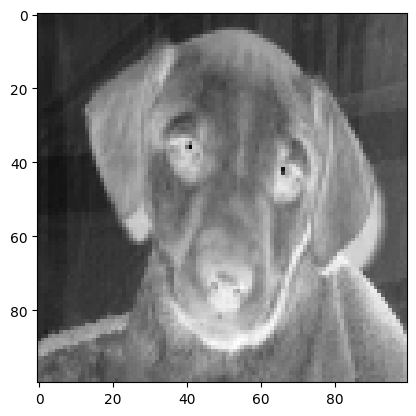

In [23]:
plt.imshow( image_train[1], cmap = plt.cm.gray_r )
plt.show()

In [126]:
model = Sequential()

In [127]:
# Define input layer
model.add(
  Input(
    shape=image_train.shape[1:],
    name="model_input",
  ),
)


In [128]:
model.add(
  Conv2D(
    name = "Conv1",
    filters = 80,
    kernel_size = (3,3),
    activation = 'sigmoid',
  )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)


In [129]:
#Define second hidden layer
model.add(
  Conv2D(
    name = "Conv2",
    filters = 80,
    kernel_size = (3,3),
    activation = 'sigmoid',
  )
)

model.add(
  MaxPooling2D(pool_size=(2,2))
)


In [130]:
model.add(
    Flatten()
)

# Define output layer
model.add(
  Dense(
    name = "output",
    units = 2,
    activation = 'sigmoid',
  )
)


In [131]:
# Compile model
model.compile(
  optimizer = 'adam',
  loss = 'sparse_categorical_crossentropy',
  metrics = ['accuracy'],
)


In [132]:
model.fit(image_train, target_train, epochs=5)

Epoch 1/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.5343 - loss: 5.6915
Epoch 2/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.5343 - loss: 1.1151
Epoch 3/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.5343 - loss: 0.6920
Epoch 4/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.5343 - loss: 0.6916
Epoch 5/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 982ms/step - accuracy: 0.5343 - loss: 0.6928


In [133]:
# *(500 images) (2 hidden) (epoch = 5) (test=30%) (sigmoid)
# attempt 1: accur - 0.4829 loss - 0.6928 ( both filters=40)
# attempt 2: accur - 0.4657 loss - 0.6999 ( both filters=60)
# attempt 3: accur - 0.5343 loss - 0.6912 ( both filters=80)

In [115]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 98, 98, 80)     │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 49, 49, 80)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 47, 47, 80)     │        57,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 23, 23, 80)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 42320)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │        84,642 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 429,368 (1.64 MB)

 Trainable params: 143,122 (559.07 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 286,246 (1.09 MB)

In [116]:
# Testing (The results that matter)
val_loss, val_acc = model.evaluate(image_test, target_test)
print(val_loss)
print(val_acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step - accuracy: 0.4933 - loss: 0.6978
0.6978158950805664
0.4933333396911621


In [ ]:
# *(500 images) (2 hidden) (epoch = 2) (test=30%)
# 1st attempt: Accuracy - 0.692  loss - 0.493 ( both filters = 40)
# 2nd attempt: Accuracy -   loss -  ( both filters = 64)
# 3rd attempt: Accuracy - 0.4933  loss - 0.6978 ( both filters = 80)

In [35]:
predictions = model.predict(image_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step


In [36]:
predictions.shape

(150, 2)

([(0, np.float32(50.65946)), (1, np.float32(49.340546))], np.int64(1))

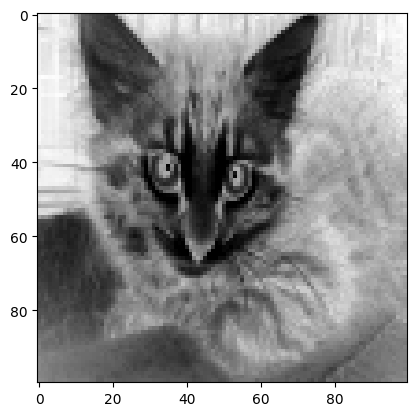

In [38]:
# print out the images
i = 0
filter = ( (predictions).argmax( axis = 1 ) != target_test )
plt.imshow(image_test[ filter ][i], cmap=plt.cm.gray_r)
list(enumerate(predictions[filter][i]*100)), target_test[filter][i]


0: 50.94
1: 49.06
0
1


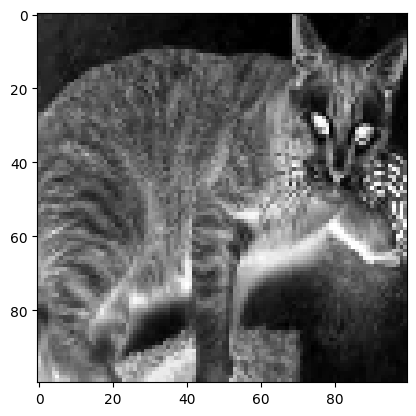

In [40]:
# pick any image from 0 to 27,000
i = 90
# i = 160
# i = 2982


for k, x in enumerate(predictions[i]*100):
  print(f"{k}: {x:.2f}")
print(np.argmax(predictions[i]))
print(target_test[i])
plt.imshow(image_test[i], cmap=plt.cm.gray_r)
plt.show()

## Communication of Results



* Communicate the results of your analysis.



## **BONUS** (optional)



* Upload an image of your (or your friend's or family's) dog or cat and use your model to predict whether the image is a dog or cat.
* Hint: you'll probably need to convert the image from color to grayscale.  OpenCV, pillow, and other libraries are your friend.